# Import thư viện

In [27]:
import pandas as pd
import matplotlib as plt
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

## Đọc dữ liệu từ file csv

In [28]:
df_th = pd.read_csv('C:\\CS114\\th-public.csv')
df_ck = pd.read_csv('C:\\CS114\\ck-public.csv')
df_qt = pd.read_csv('C:\\CS114\\qt-public.csv')
df_total = pd.read_csv('C:\\CS114\\annonimized.csv')

## Tổng quan về dữ liệu

In [29]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


In [30]:
df_ck.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hash    761 non-null    object 
 1   CK      755 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


In [31]:
df_qt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   hash    761 non-null    object
 1   diemqt  755 non-null    object
dtypes: object(2)
memory usage: 12.0+ KB


In [32]:
df_th.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   hash    761 non-null    object
 1   TH      755 non-null    object
dtypes: object(2)
memory usage: 12.0+ KB


### Chuyển cột điểm từ dạng chuỗi thành dạng số

In [33]:
df_ck['CK'] = pd.to_numeric(df_ck['CK'], errors='coerce')
df_qt['diemqt'] = pd.to_numeric(df_qt['diemqt'], errors='coerce')
df_th['TH'] = pd.to_numeric(df_th['TH'], errors='coerce')

## Ghép dữ liệu các cột đặc trưng với dữ liệu điểm thông qua mssv

In [34]:
df = pd.merge(df_total, df_qt, left_on="concat('it001', username)", right_on='hash', how='outer')
df = pd.merge(df, df_th, left_on="concat('it001', username)", right_on='hash', how='outer')
df = pd.merge(df, df_ck, left_on="concat('it001', username)", right_on='hash', how='outer')

### Xóa các đặc trưng không cần dùng để dự đoán điểm

In [35]:
delete_columns = ['created_at', 'updated_at', 'hash_x', 'hash_y']
df = df.drop(columns=delete_columns)

In [36]:
def extract_judgement_info(row):
    try:
        data = json.loads(row)
        times = data.get("times", [])
        mems = data.get("mems", [])
        verdicts = data.get("verdicts", {})

        avg_time = np.mean(times) if times else 0
        max_time = np.max(times) if times else 0

        avg_mem = np.mean(mems) if mems else 0
        max_mem = np.max(mems) if mems else 0

        n_wrong = verdicts.get("WRONG", 0)
        n_tle = verdicts.get("Time Limit Exceeded", 0)
        n_failed = n_wrong + n_tle

        return pd.Series([n_failed, avg_time, max_time, avg_mem, max_mem])
    except:
        return pd.Series([0, 0, 0, 0, 0])

df[['n_failed', 'avg_time', 'max_time', 'avg_mem', 'max_mem']] = df['judgement'].apply(extract_judgement_info)
df['n_failed'] = df['n_failed'].astype('Int64')
df.drop(columns=['judgement'], inplace=True)

df['code_runnable'] = (df['status'] == 'SCORE').astype(int)
df['compile_error'] = (df['status'] == 'Compilation Error').astype(int)
df['syntax_error'] = (df['status'] == 'Syntax Error').astype(int)
df['pending'] = (df['status'] == 'pending').astype(int)
df.drop(columns=['status'], inplace=True)

df = df.groupby("concat('it001', username)").agg({
    "concat('it001',`assignment_id`)": pd.Series.nunique,
    "concat('it001',`problem_id`)": pd.Series.nunique,
    'pre_score': 'mean',
    'coefficient': 'mean',
    "concat('it001',`language_id`)": pd.Series.nunique,
    'is_final': 'sum',
    'n_failed': 'sum',
    'avg_time': ['mean', 'max'],
    'avg_mem': ['mean', 'max'],
    'max_time': ['mean', 'max'],
    'max_mem': ['mean', 'max'],
    'code_runnable': 'sum',
    'compile_error': 'sum',
    'syntax_error': 'sum',
    'pending': 'sum',
    'TH': 'first',
    'diemqt': 'first',
    'CK': 'first',
})

df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

df = df.rename(columns={
    "concat('it001',`assignment_id`)_nunique": 'n_assignments',
    "concat('it001',`problem_id`)_nunique": 'n_problems',
    'pre_score_mean': 'pre_score',
    'coefficient_mean': 'coefficient',
    "concat('it001',`language_id`)_nunique": 'n_languages',
    'is_final_sum': 'is_final',
    'n_failed_sum': 'n_failed',
    'avg_time_mean': 'mean(avg_time)',
    'avg_time_max': 'max(avg_time)',
    'avg_mem_mean': 'mean(avg_mem)',
    'avg_mem_max': 'max(avg_mem)',
    'max_time_mean': 'mean(max_time)',
    'max_time_max': 'max(max_time)',
    'max_mem_mean': 'mean(max_mem)',
    'max_mem_max': 'max(max_mem)',
    'code_runnable_sum': 'n_code_runnable',
    'compile_error_sum': 'n_compile_error',
    'syntax_error_sum': 'n_syntax_error',
    'pending_sum': 'n_pending',
    'TH_first': 'TH',
    'diemqt_first': 'QT',
    'CK_first': 'CK',
})

df = df.reset_index()

In [37]:
df.head()

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,n_failed,mean(avg_time),max(avg_time),...,max(max_time),mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,n_syntax_error,n_pending,TH,QT,CK
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,100.000000,1,46,484,0.009621,0.510769,...,0.94,128.163265,2768.0,119,28,0,0,5.0,7.5,5.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,100.000000,1,78,555,0.009392,0.606154,...,1.02,201.698842,2644.0,209,50,0,0,8.5,7.0,6.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,100.000000,1,67,965,0.017642,0.524000,...,0.55,389.128205,10200.0,175,20,0,0,7.0,9.0,4.5
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,5952.760000,100.000000,1,47,174,0.005910,0.534000,...,0.55,59.520000,1984.0,76,24,0,0,NaN,NaN,NaN
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,97.196262,1,66,260,0.031732,0.803571,...,1.06,259.588785,1984.0,94,13,0,0,10.0,10.0,5.0


### Chia dữ liệu thành tập train / test

In [39]:
df_final = df[df[['CK', 'TH', 'QT']].notna().all(axis=1)]

X = df_final.drop(columns=["concat('it001', username)", 'CK', 'TH', 'QT'])
y = df_final[['CK', 'TH', 'QT']]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


test_df = df[~df[['CK', 'TH', 'QT']].notna().all(axis=1)]
X_test = test_df.drop(columns=["concat('it001', username)", 'CK', 'TH', 'QT'])

In [40]:
df_final

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,n_failed,mean(avg_time),max(avg_time),...,max(max_time),mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,n_syntax_error,n_pending,TH,QT,CK
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,100.000000,1,46,484,0.009621,0.510769,...,0.94,128.163265,2768.0,119,28,0,0,5.0,7.5,5.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,100.000000,1,78,555,0.009392,0.606154,...,1.02,201.698842,2644.0,209,50,0,0,8.5,7.0,6.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,100.000000,1,67,965,0.017642,0.524000,...,0.55,389.128205,10200.0,175,20,0,0,7.0,9.0,4.5
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,97.196262,1,66,260,0.031732,0.803571,...,1.06,259.588785,1984.0,94,13,0,0,10.0,10.0,5.0
5,014c59c6433fd764a0b08de6ffeb757eaf60aa73,9,90,5240.025126,100.000000,1,90,528,0.000000,0.000000,...,0.00,39.879397,1984.0,154,45,0,0,6.0,9.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,840d07858c03f80f4695056e2cc7d0c474b83a25,6,43,5171.639640,100.000000,1,44,249,0.001043,0.054000,...,0.54,53.621622,1984.0,81,30,0,0,6.0,9.0,5.5
797,844f5db2e7e31ae51eba025480679ed7e4708ac6,17,104,4785.224090,100.000000,1,104,922,0.011511,0.606154,...,0.98,145.535014,10044.0,254,103,0,0,8.5,8.0,6.0
798,845acd04a77b3d1b623f255d9f9f8eae90892dab,8,52,4247.296774,100.000000,1,53,505,0.002995,0.233333,...,0.52,64.929032,2128.0,117,38,0,0,5.5,6.5,6.0
799,8460eaaf887a6289fb156f7562fb739ba8e9629e,12,114,4278.605027,100.000000,1,115,2019,0.009255,0.605000,...,0.94,412.193896,10044.0,416,141,0,0,10.0,10.0,7.0


### Huấn luyện

In [41]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Dự đoán và đánh giá trên tập kiểm định

In [42]:
y_pred_val = model.predict(X_val)
print("R^2 score trên tập kiểm định:", r2_score(y_val, y_pred_val))

R^2 score trên tập kiểm định: 0.21622722130124364


### Dự đoán kết quả trên tập test

In [43]:
test_df[['CK', 'TH', 'QT']] = model.predict(X_test)

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_1680\3811814870.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[['CK', 'TH', 'QT']] = model.predict(X_test)


In [44]:
test_df

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,n_failed,mean(avg_time),max(avg_time),...,max(max_time),mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,n_syntax_error,n_pending,TH,QT,CK
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,5952.760000,100.0,1,47,174,0.005910,0.534000,...,0.55,59.520000,1984.0,76,24,0,0,5.510,7.000,3.500
20,035f97702f2c01d26ab1fae8f39ea2f98a0caa3c,4,50,5035.763889,100.0,1,50,385,0.000000,0.000000,...,0.00,41.333333,1984.0,103,41,0,0,5.970,7.800,3.600
40,06024da8147b5cf6105beb4c403f67cf1ff0aea1,1,5,6778.750000,100.0,1,5,2,0.002260,0.018077,...,0.02,10515.500000,80272.0,8,0,0,0,6.595,8.645,5.760
68,0aaebc88f6106684d6993c156104c1ef36cf94e0,4,50,4065.369792,100.0,1,50,766,0.002734,0.160000,...,0.53,104.375000,2184.0,149,43,0,0,5.985,7.750,4.590
80,0bf111a9caedf02804f6991792490e63bc21058a,6,65,6355.753769,100.0,1,82,856,0.008514,0.373415,...,0.55,191.115578,6508.0,176,23,0,0,7.980,8.695,5.790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,feb8a2859a011c59efd22ed419cb69288fe03627,9,34,5581.081081,100.0,1,34,32,0.000000,0.000000,...,0.00,0.000000,0.0,71,3,0,0,7.660,8.985,7.020
1485,fef4a3263ed9a8ab14d457694bb8fd86ccd98312,6,77,6204.557692,100.0,1,78,657,0.001685,0.438000,...,0.54,68.769231,1988.0,216,44,0,0,7.235,8.200,4.415
1486,ff12d6e2ab80696ed8e22fbe5497e96c68d29076,6,100,4998.466819,100.0,1,103,1650,0.024376,0.605769,...,0.94,227.643021,10044.0,360,77,0,0,8.085,8.615,5.415
1487,ff3fa2ec64294f37ae968159f810ebeda7966c51,7,34,4343.329787,100.0,1,34,448,0.020378,0.371579,...,0.55,188.042553,3548.0,74,20,0,0,6.040,8.095,5.355


In [45]:
test_df['TBTL'] = test_df['TH'] * 0.4 + test_df['QT'] * 0.2 + test_df['CK'] * 0.4

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_1680\2418525902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['TBTL'] = test_df['TH'] * 0.4 + test_df['QT'] * 0.2 + test_df['CK'] * 0.4


In [46]:
test_df

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,n_failed,mean(avg_time),max(avg_time),...,mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,n_syntax_error,n_pending,TH,QT,CK,TBTL
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,5952.760000,100.0,1,47,174,0.005910,0.534000,...,59.520000,1984.0,76,24,0,0,5.510,7.000,3.500,5.004
20,035f97702f2c01d26ab1fae8f39ea2f98a0caa3c,4,50,5035.763889,100.0,1,50,385,0.000000,0.000000,...,41.333333,1984.0,103,41,0,0,5.970,7.800,3.600,5.388
40,06024da8147b5cf6105beb4c403f67cf1ff0aea1,1,5,6778.750000,100.0,1,5,2,0.002260,0.018077,...,10515.500000,80272.0,8,0,0,0,6.595,8.645,5.760,6.671
68,0aaebc88f6106684d6993c156104c1ef36cf94e0,4,50,4065.369792,100.0,1,50,766,0.002734,0.160000,...,104.375000,2184.0,149,43,0,0,5.985,7.750,4.590,5.780
80,0bf111a9caedf02804f6991792490e63bc21058a,6,65,6355.753769,100.0,1,82,856,0.008514,0.373415,...,191.115578,6508.0,176,23,0,0,7.980,8.695,5.790,7.247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,feb8a2859a011c59efd22ed419cb69288fe03627,9,34,5581.081081,100.0,1,34,32,0.000000,0.000000,...,0.000000,0.0,71,3,0,0,7.660,8.985,7.020,7.669
1485,fef4a3263ed9a8ab14d457694bb8fd86ccd98312,6,77,6204.557692,100.0,1,78,657,0.001685,0.438000,...,68.769231,1988.0,216,44,0,0,7.235,8.200,4.415,6.300
1486,ff12d6e2ab80696ed8e22fbe5497e96c68d29076,6,100,4998.466819,100.0,1,103,1650,0.024376,0.605769,...,227.643021,10044.0,360,77,0,0,8.085,8.615,5.415,7.123
1487,ff3fa2ec64294f37ae968159f810ebeda7966c51,7,34,4343.329787,100.0,1,34,448,0.020378,0.371579,...,188.042553,3548.0,74,20,0,0,6.040,8.095,5.355,6.177


In [47]:
df_final['TBTL'] = df_final['TH'] * 0.4 + df_final['QT'] * 0.2 + df_final['CK'] * 0.4

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_1680\931119876.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['TBTL'] = df_final['TH'] * 0.4 + df_final['QT'] * 0.2 + df_final['CK'] * 0.4


### Lưu kết quả điểm vào file csv để nộp

In [48]:
combined_df = pd.concat([
    df_final[["concat('it001', username)", 'TBTL']],
    test_df[["concat('it001', username)", 'TBTL']]
])

combined_df.to_csv('result.csv', index=False, header=False, encoding='utf-8')

### Lưu bộ siêu tham số tốt nhất

In [49]:
joblib.dump(model, 'best_model.pkl')

['best_model.pkl']

### Vẽ biểu đồ các đặc trưng trên

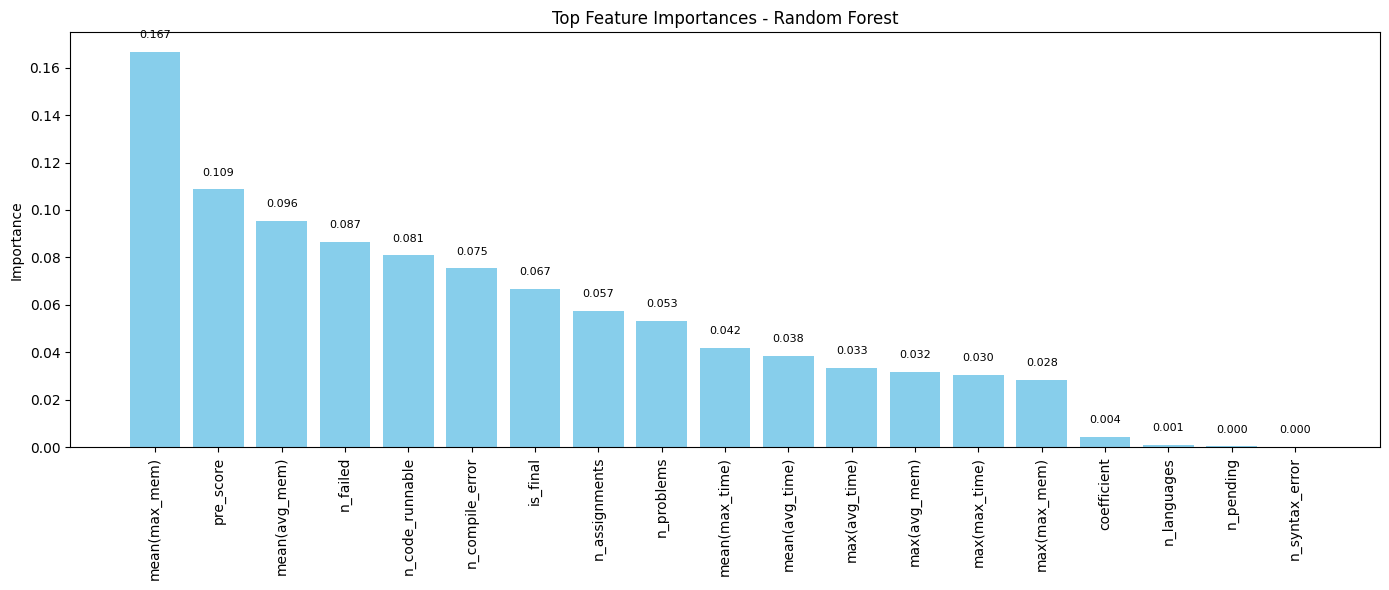

In [50]:
importances = model.feature_importances_
feature_names = X_train.columns

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

top_k = min(20, len(importances))
sorted_importances = sorted_importances[:top_k]
sorted_features = sorted_features[:top_k]

# Vẽ
plt.figure(figsize=(14, 6))
bars = plt.bar(range(top_k), sorted_importances, color='skyblue', align='center')
plt.xticks(range(top_k), sorted_features, rotation=90)
plt.title('Top Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()

# Ghi nhãn số
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.005, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.show()


In [52]:
df = pd.concat([df_final,test_df])

In [53]:
df

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,n_failed,mean(avg_time),max(avg_time),...,mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,n_syntax_error,n_pending,TH,QT,CK,TBTL
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,100.000000,1,46,484,0.009621,0.510769,...,128.163265,2768.0,119,28,0,0,5.000,7.500,5.500,5.700
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,100.000000,1,78,555,0.009392,0.606154,...,201.698842,2644.0,209,50,0,0,8.500,7.000,6.500,7.400
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,100.000000,1,67,965,0.017642,0.524000,...,389.128205,10200.0,175,20,0,0,7.000,9.000,4.500,6.400
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,97.196262,1,66,260,0.031732,0.803571,...,259.588785,1984.0,94,13,0,0,10.000,10.000,5.000,8.000
5,014c59c6433fd764a0b08de6ffeb757eaf60aa73,9,90,5240.025126,100.000000,1,90,528,0.000000,0.000000,...,39.879397,1984.0,154,45,0,0,6.000,9.000,4.000,5.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,feb8a2859a011c59efd22ed419cb69288fe03627,9,34,5581.081081,100.000000,1,34,32,0.000000,0.000000,...,0.000000,0.0,71,3,0,0,7.660,8.985,7.020,7.669
1485,fef4a3263ed9a8ab14d457694bb8fd86ccd98312,6,77,6204.557692,100.000000,1,78,657,0.001685,0.438000,...,68.769231,1988.0,216,44,0,0,7.235,8.200,4.415,6.300
1486,ff12d6e2ab80696ed8e22fbe5497e96c68d29076,6,100,4998.466819,100.000000,1,103,1650,0.024376,0.605769,...,227.643021,10044.0,360,77,0,0,8.085,8.615,5.415,7.123
1487,ff3fa2ec64294f37ae968159f810ebeda7966c51,7,34,4343.329787,100.000000,1,34,448,0.020378,0.371579,...,188.042553,3548.0,74,20,0,0,6.040,8.095,5.355,6.177


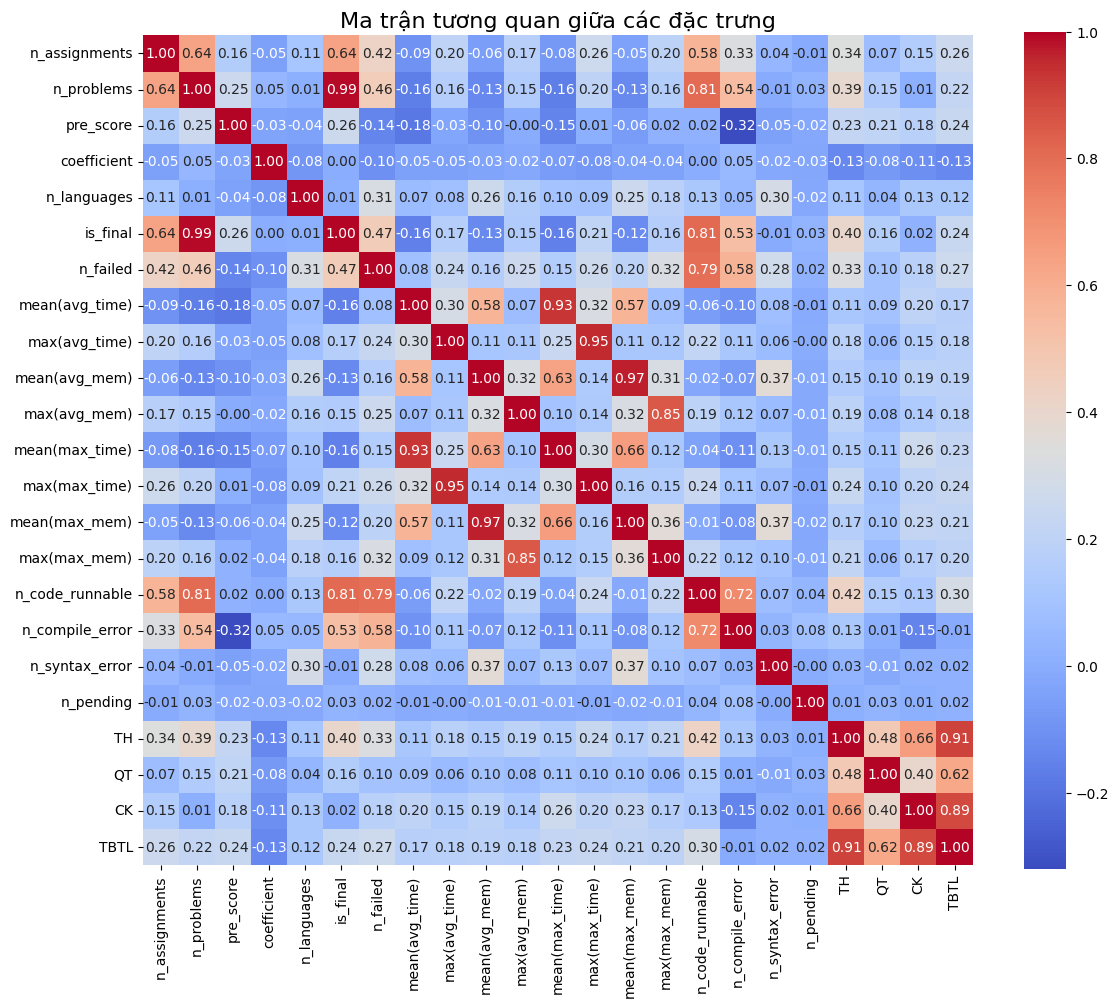

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính ma trận tương quan
corr_matrix = df.corr(numeric_only=True)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Ma trận tương quan giữa các đặc trưng", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
